## 8.8 양자 푸리에 변환과 경제물리학

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_city
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 경제 시스템을 표현할 큐비트 수 정의
n_qubits = 4

In [3]:
# n_qubits개의 양자회로 생성
qc = QuantumCircuit(n_qubits)

In [4]:
# 하다마드 게이트로 큐비트를 중첩에 둠 - 경제 시스템 다각화에 비유
for qubit in range(n_qubits):
    qc.h(qubit)

In [5]:
# 일련의 제어 위상 이동으로 단순 경제 교란 모델링
qc.cp(0.1, 0, 1)
qc.cp(0.2, 1, 2)
qc.cp(0.3, 2, 3)

In [6]:
# 경제 시스템을 분석하기 위해 양자 푸리에 변환 적용
qc.append(QFT(num_qubits=n_qubits, inverse=False), range(n_qubits))

/sessions/eloquent-vigilant-lovelace/tmp/ipykernel_67/593149120.py:2: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(num_qubits=n_qubits, inverse=False), range(n_qubits))


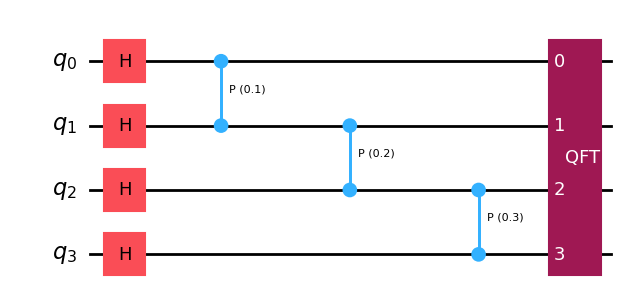

In [7]:
# 회로 시각화
qc.draw('mpl')
plt.show()

In [8]:
# AerSimulator 백엔드용으로 회로 트랜스파일
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)

In [9]:
# 양자회로에서 상태벡터 획득 (측정 없이)
statevector = Statevector.from_instruction(qc)
density_matrix = DensityMatrix(statevector)

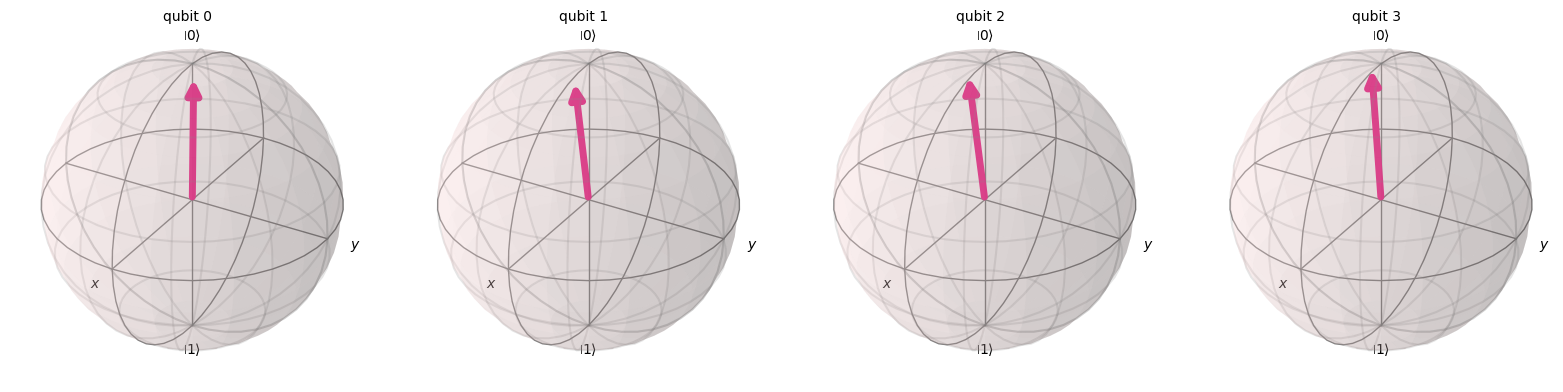

In [10]:
# 블로흐 구 시각화 (개별 큐비트)
plot_bloch_multivector(statevector)
plt.show()

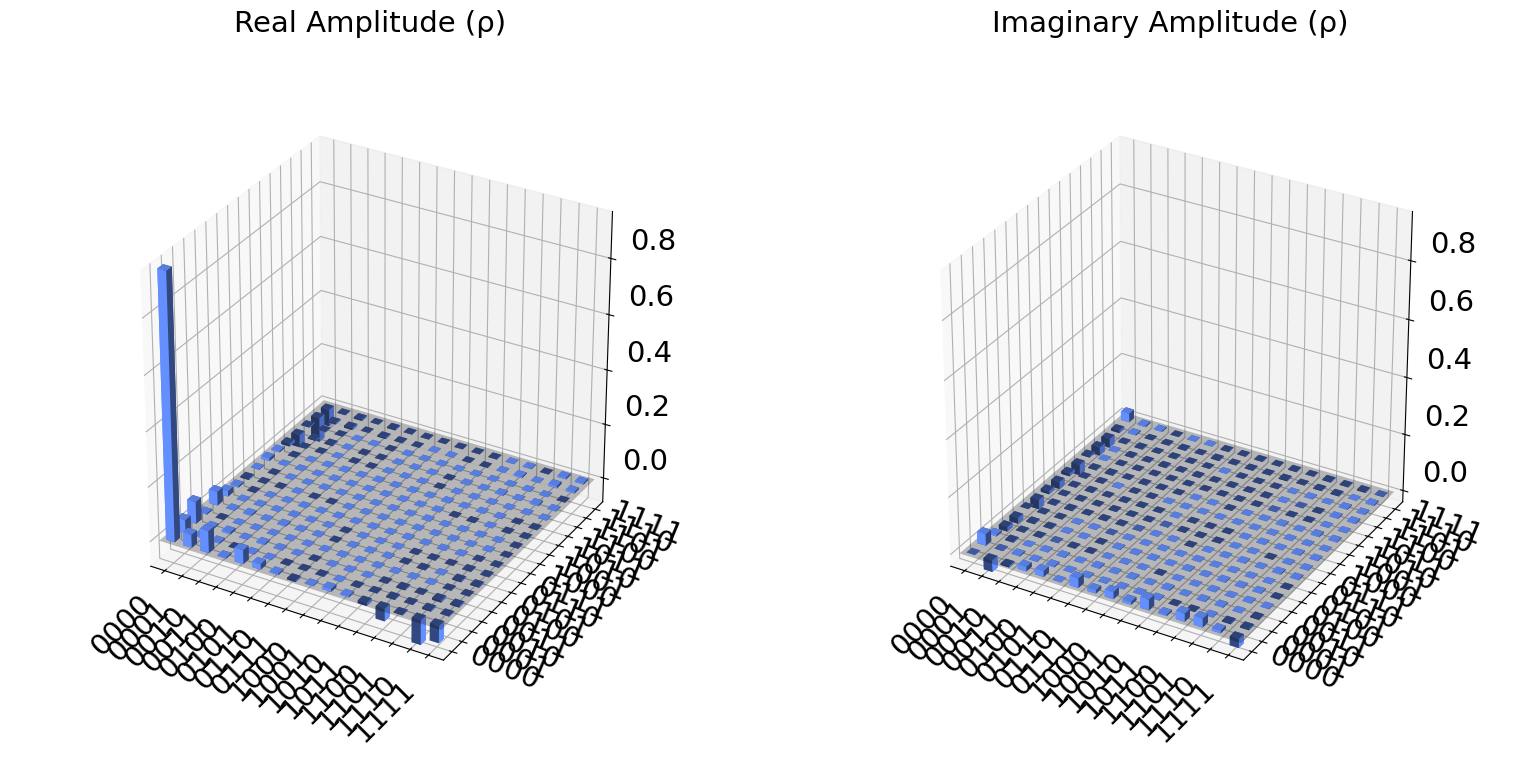

In [11]:
# state city로 밀도행렬 시각화
plot_state_city(density_matrix)
plt.show()

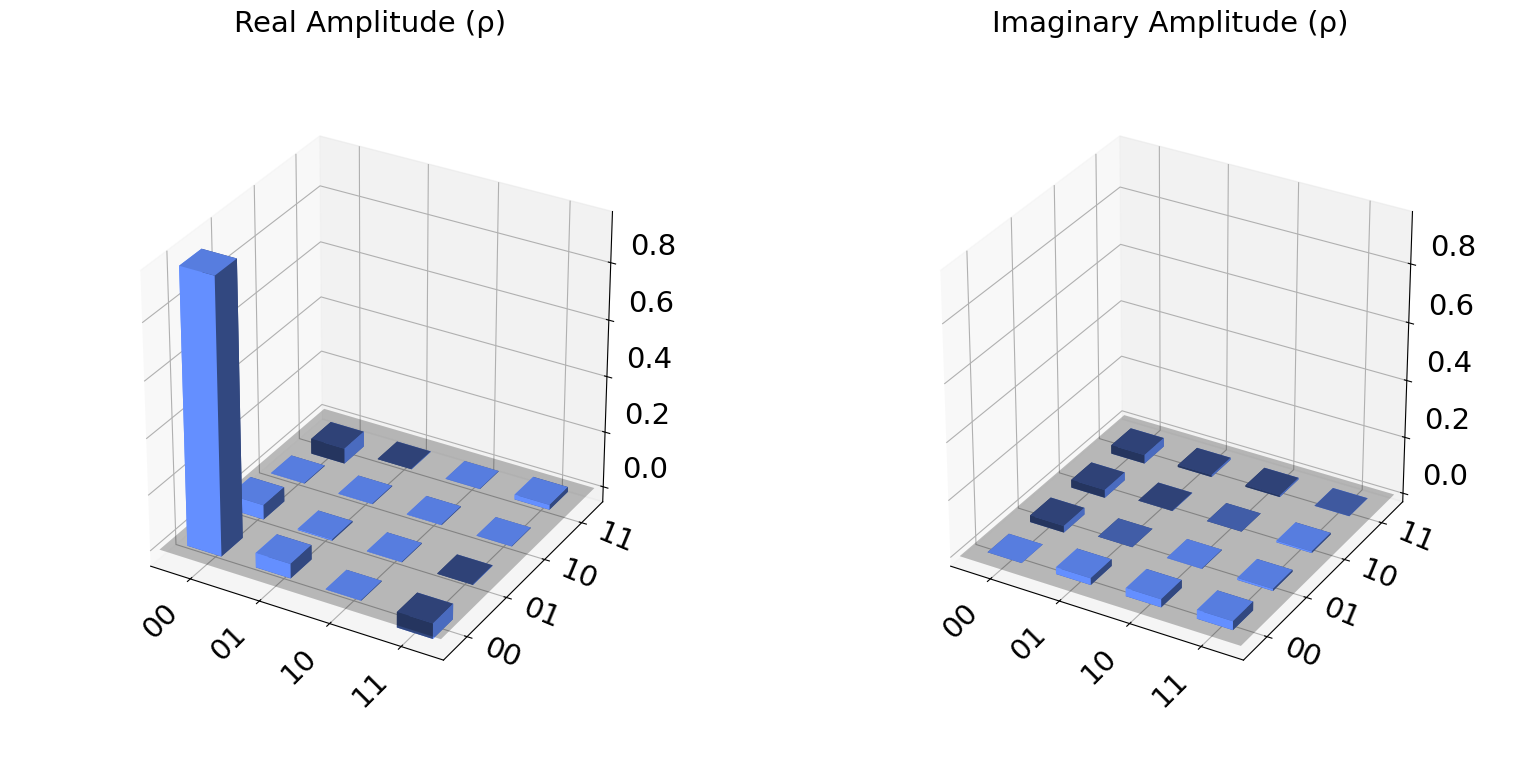

In [12]:
# 부분 대각합으로 부분계 분석 (더 복잡한 경제 분석)
subsystem_trace = partial_trace(density_matrix, [0, 1])
plot_state_city(subsystem_trace)
plt.show()

In [13]:
# 측정
qc.measure_all()
result = simulator.run(transpile(qc, simulator)).result()
counts = result.get_counts()

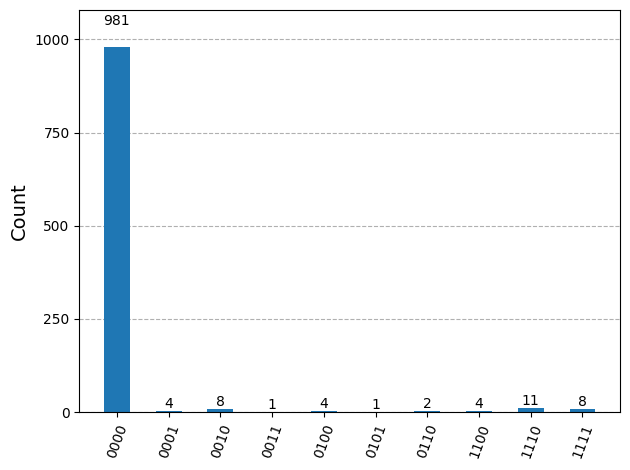

In [14]:
# 히스토그램 그리기
plot_histogram(counts)
plt.show()